In [75]:
!pip install kagglehub


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/web-network")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\miche\.cache\kagglehub\datasets\willianoliveiragibin\web-network\versions\2


In [77]:
import pandas as pd
import time
import numpy as np

In [78]:
df=pd.read_csv(path+"/test traficct new.csv")


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   method            522 non-null    str  
 1   path              522 non-null    str  
 2   single_q          522 non-null    int64
 3   double_q          522 non-null    int64
 4   dashes            522 non-null    int64
 5   braces            522 non-null    int64
 6   spaces            522 non-null    int64
 7   percentages       522 non-null    int64
 8   semicolons        522 non-null    int64
 9   angle_brackets    522 non-null    int64
 10  special_chars     522 non-null    int64
 11  path_length       522 non-null    int64
 12  body_length       522 non-null    int64
 13  badwords_count    522 non-null    int64
 14  single_q.1        522 non-null    int64
 15  double_q.1        522 non-null    int64
 16  dashes.1          522 non-null    int64
 17  braces.1          522 non-null    int64
 18  s

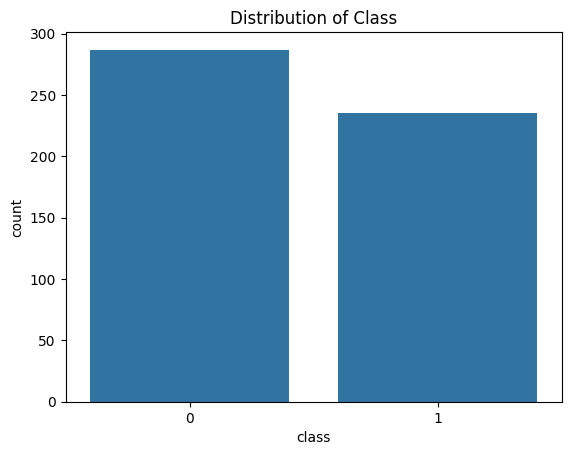

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='class', data=df)
plt.title('Distribution of Class')
plt.show()

### Obiettivo: usare K-fold cross-validation per trovare il miglior valore di K per il modello KNN

In [81]:
from sklearn.model_selection import train_test_split

y = df['class']

X = df.drop(columns=['class', 'prediction'])
X = X.select_dtypes(include=[np.number])

# Split train / test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

#Perchè non stiamo creando la parte di validazione???

Train: (417, 24)
Test: (105, 24)


single_q               0.000000
double_q               0.000000
dashes                 0.000000
braces                 0.000000
percentages            0.000000
semicolons             0.000000
angle_brackets         0.000000
special_chars          0.000000
special_chars.1        0.000000
percentages.1          0.000000
badwords_count         0.041793
dashes.1               0.098379
semicolons.1           0.511944
angle_brackets.1       0.640807
braces.1               0.712899
spaces                 0.823268
badwords_count.1       1.853798
double_q.1             2.077719
single_q.1             2.154757
spaces.1              28.698683
body_length          246.557323
path_length          435.464063
path_length.1       2374.913738
body_length.1       3298.526390
dtype: float64
spaces.1           28.698683
body_length       246.557323
path_length       435.464063
path_length.1    2374.913738
body_length.1    3298.526390
dtype: float64


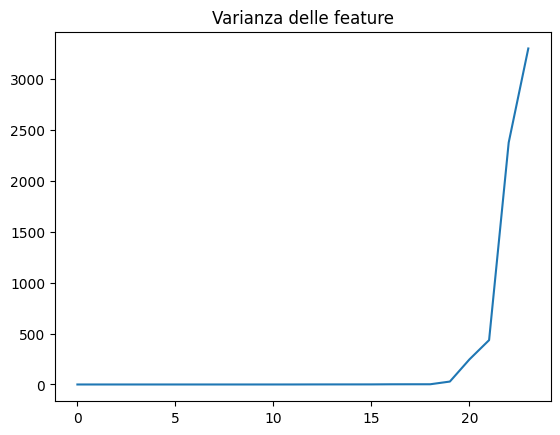

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.feature_selection import VarianceThreshold

# calcolo i valori di varianza e li ordiniamo dal più piccolo al più grande
variances = X_train.var().sort_values()
print(variances.head(30))   # le più basse

print(variances.tail(5))   # le più alte

plt.plot(variances.values[:100])
plt.title("Varianza delle feature")
plt.show()

In [83]:
threshold = 0.02
selected_features = variances[variances > threshold].index
X_train_var = X_train[selected_features]
X_test_var = X_test[selected_features]

X_train_var

,badwords_count,dashes.1,semicolons.1,angle_brackets.1,braces.1,spaces,badwords_count.1,double_q.1,single_q.1,spaces.1,body_length,path_length,path_length.1,body_length.1
336,0,0,0,0,0,0,0,0,0,0,0,0,10,0
174,0,0,0,0,1,0,1,2,0,0,0,0,70,0
375,0,0,0,0,0,0,0,0,0,0,0,0,39,0
74,0,0,0,0,0,0,1,0,0,0,0,39,8,65
126,0,1,1,0,1,0,4,2,4,14,0,0,177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,0,0,0,0,0,0,0,0,0,0,0,0,84,0
140,0,1,1,0,1,0,4,2,4,14,0,0,189,0
257,0,0,0,0,0,0,0,0,0,0,0,0,43,0
85,0,0,0,0,0,0,0,0,0,2,0,41,13,114


### Abbiamo 14 feature, non sono tantissime: in questa fase non ci interessiamo di feature selection in maniera troppo precisa.

Verifichiamo giusto che non ci siano feature ridondanti

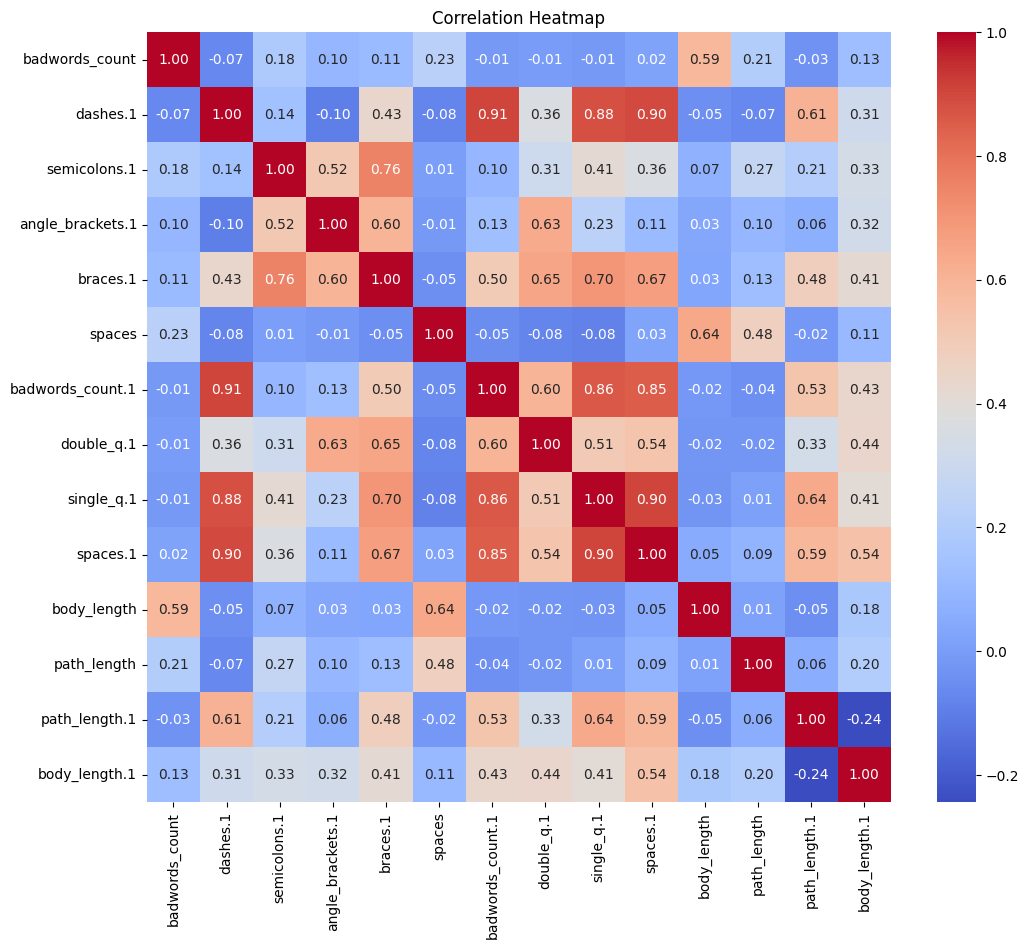

In [84]:
# numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_var.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Rimozione di feature ridondanti

La correlazione tra feature viene calcolata solo sul training set, così la scelta delle feature da eliminare non usa informazioni del test set. 

In [85]:
corr_matrix = X_train_var.corr().abs()

# prendiamo solo la parte superiore (evita duplicati)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# soglia
threshold = 0.85 #decidiamo la soglia di ridondanza tra features

# colonne da eliminare
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Feature rimosse per alta correlazione:")
print(to_drop)

# Applichiamo la selezione
X_train_reduced = X_train_var.drop(columns=to_drop)
X_test_reduced = X_test_var.drop(columns=to_drop)

print("Originale:")
print("X_train:", X_train.shape)

print("\nDopo rimozione varianza bassa:")
print("X_train_var:", X_train_var.shape)

print("\nDopo rimozione feature correlate:")
print("X_train_reduced:", X_train_reduced.shape)

Feature rimosse per alta correlazione:
['badwords_count.1', 'single_q.1', 'spaces.1']
Originale:
X_train: (417, 24)

Dopo rimozione varianza bassa:
X_train_var: (417, 14)

Dopo rimozione feature correlate:
X_train_reduced: (417, 11)


### Risolviamo il problema con KNN utilizzando Scikit-Learn e k-fold (con pipeline)

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

# Usiamo una Pipeline per evitare data leakage durante la cross-validation:
# lo scaler viene calcolato separatamente in ogni fold usando solo i dati di training,
# e poi applicato al fold di validazione.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Quando si usa una Pipeline, i parametri vanno specificati indicando lo step:
# "knn__" significa "parametro del classificatore KNN dentro la pipeline".
param_grid = {
    'knn__n_neighbors': range(1, 31, 2),     # Valori dispari da 1 a 29
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [87]:
# Creiamo il modello KNN
knn = KNeighborsClassifier()

# Creiamo e addestriamo il GridSearchCV
start_time = time.time()


grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5, 
    scoring="accuracy",
    n_jobs=-1  # Usa tutti i core disponibili
)

print("Inizio ricerca parametri ottimali...")
grid_search.fit(X_train_reduced, y_train)
print(f"Ricerca completata in {time.time() - start_time:.2f} secondi")

Inizio ricerca parametri ottimali...
Ricerca completata in 10.59 secondi


Miglior combinazione di parametri: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Miglior score (accuracy): 0.9712
Accuratezza sul test set: 0.9714


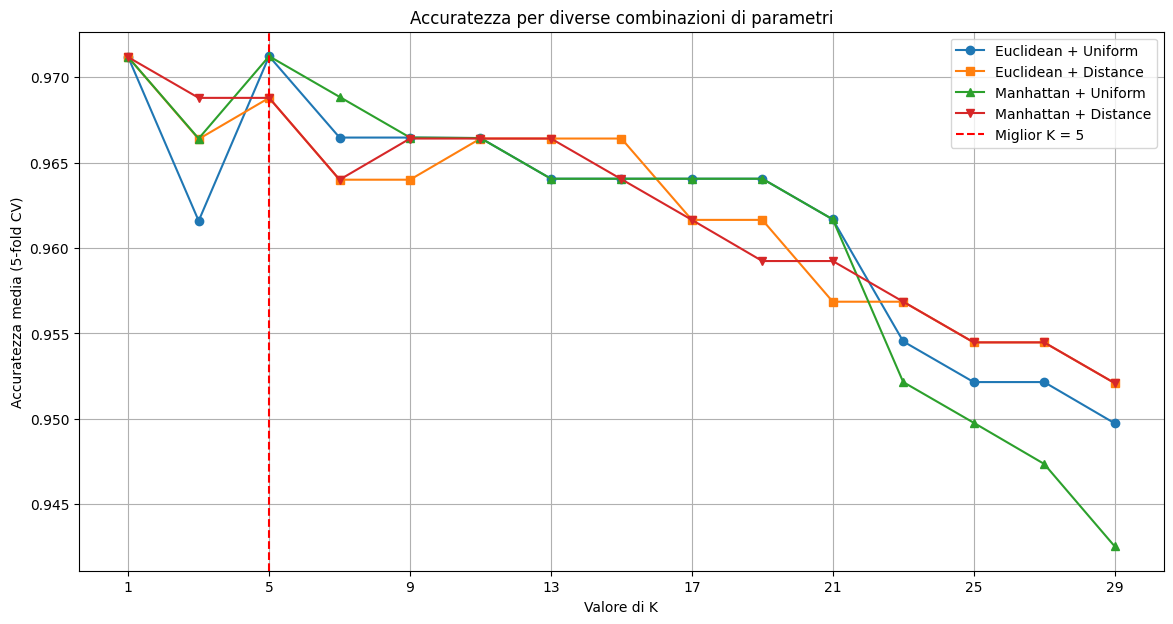

In [88]:
# Risultati
print(f"Miglior combinazione di parametri: {grid_search.best_params_}")
print(f"Miglior score (accuracy): {grid_search.best_score_:.4f}")

# Valutiamo sul test set
best_model = grid_search.best_estimator_
accuracy = best_model.score(X_test_reduced, y_test)
print(f"Accuratezza sul test set: {accuracy:.4f}")

# Visualizziamo i risultati per K
k_values = param_grid['knn__n_neighbors']
cv_results = grid_search.cv_results_

# Estraiamo i risultati solo per weights='uniform' e metric='manhattan'
mask = (cv_results['param_knn__weights'] == 'uniform') & \
       (cv_results['param_knn__metric'] == 'manhattan')
       
k_scores = [cv_results['mean_test_score'][i] for i, m in enumerate(mask) if m]

# Visualizziamo i risultati per tutte le combinazioni di parametri
plt.figure(figsize=(14, 7))

# Per metric='euclidean'
mask_euclidean_uniform = (cv_results['param_knn__metric'] == 'euclidean') & \
                        (cv_results['param_knn__weights'] == 'uniform')
                         
mask_euclidean_distance = (cv_results['param_knn__metric'] == 'euclidean') & \
                         (cv_results['param_knn__weights'] == 'distance')

euclidean_uniform_scores = [cv_results['mean_test_score'][i] for i, m in enumerate(mask_euclidean_uniform) if m]
euclidean_distance_scores = [cv_results['mean_test_score'][i] for i, m in enumerate(mask_euclidean_distance) if m]

# Per metric='manhattan'
mask_manhattan_uniform = (cv_results['param_knn__metric'] == 'manhattan') & \
                        (cv_results['param_knn__weights'] == 'uniform')
                         
mask_manhattan_distance = (cv_results['param_knn__metric'] == 'manhattan') & \
                         (cv_results['param_knn__weights'] == 'distance')

manhattan_uniform_scores = [cv_results['mean_test_score'][i] for i, m in enumerate(mask_manhattan_uniform) if m]
manhattan_distance_scores = [cv_results['mean_test_score'][i] for i, m in enumerate(mask_manhattan_distance) if m]

plt.plot(k_values, euclidean_uniform_scores, 'o-', label='Euclidean + Uniform')
plt.plot(k_values, euclidean_distance_scores, 's-', label='Euclidean + Distance')
plt.plot(k_values, manhattan_uniform_scores, '^-', label='Manhattan + Uniform')
plt.plot(k_values, manhattan_distance_scores, 'v-', label='Manhattan + Distance')

plt.axvline(x=grid_search.best_params_['knn__n_neighbors'], color='red', linestyle='--', 
           label=f"Miglior K = {grid_search.best_params_['knn__n_neighbors']}")

plt.title('Accuratezza per diverse combinazioni di parametri')
plt.xlabel('Valore di K')
plt.ylabel('Accuratezza media (5-fold CV)')
plt.grid(True)
plt.legend()
plt.xticks(k_values[::2])  # Mostra solo alcuni valori di K per chiarezza
plt.show()